<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/19_Uncertainty_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

Install required Python packages for the notebook.


In [ ]:
!pip install open_clip_torch ftfy regex tqdm pillow
!pip install transformers datasets

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip


In [ ]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip


## GPU Check

Verify that CUDA is available and detect the GPU.


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti


In [ ]:
!pip install "numpy<2"

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import open_clip
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

In [ ]:
class Config:
    """Global configuration for all models"""

    # Paths
    BASE_DIR = "/mnt/gdrive/MSc_Thesis_Neuroimaging"
    SPLIT_DIR = f"{BASE_DIR}/data/split"
    RESULTS_DIR = f"{BASE_DIR}/results/benchmarks"
    CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"

    # Training parameters
    BATCH_SIZE = 32
    NUM_EPOCHS = 5
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Random seed
    SEED = 42

    # Datasets to train on
    DATASETS = [
        "MRI_tumor_binary_norm",
        "MRI_ms_norm",
        "CT_stroke_binary_norm"
    ]

    # Early stopping
    PATIENCE = 10
    MIN_DELTA = 1e-3

    def __init__(self):
        os.makedirs(self.RESULTS_DIR, exist_ok=True)
        os.makedirs(self.CHECKPOINT_DIR, exist_ok=True)

## Dataset

Load the test split from the preprocessed dataset folders.


In [ ]:
class MedicalImageDataset(Dataset):
    """PyTorch Dataset for medical images with stratified splits"""

    def __init__(self, split_dir, split_type="test", transform=None):
        """
        Args:
            split_dir: path to split directory
            split_type: "train", "val", or "test"
            transform: image transformations
        """
        self.split_dir = split_dir
        self.split_type = split_type
        self.transform = transform

        self.samples = []
        self.class_to_idx = {}
        self._build_samples()

    def _build_samples(self):
        """Build list of (path, label) tuples"""
        split_path = os.path.join(self.split_dir, self.split_type)

        idx = 0
        for class_name in sorted(os.listdir(split_path)):
            class_path = os.path.join(split_path, class_name)

            if not os.path.isdir(class_path):
                continue

            if class_name not in self.class_to_idx:
                self.class_to_idx[class_name] = idx
                idx += 1

            label = self.class_to_idx[class_name]

            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from PIL import Image

        img_path, label = self.samples[idx]

        # Load as grayscale and convert to RGB (3 channels for pretrained models)
        image = Image.open(img_path).convert('L')
        image_rgb = Image.new('RGB', image.size)
        image_rgb.paste(image)

        if self.transform:
            image_rgb = self.transform(image_rgb)

        return image_rgb, label

def get_test_loader(split_dir, batch_size=16, num_workers=2, transform=None):
    """Create test DataLoader"""

    # Val/Test transforms (no augmentation)
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]) if transform is None else transform

    # Create test dataset
    test_ds = MedicalImageDataset(split_dir, "test", test_transform)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=True)

    print(f"✅ Test dataset loaded: {len(test_ds)} samples")
    print(f"📁 Classes: {list(test_ds.class_to_idx.keys())}")

    return test_loader, test_ds


In [ ]:
class UncertaintyEstimator:
    def __init__(self, model_name="hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"):
        self.model_name = model_name
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(model_name)
        self.tokenizer = open_clip.get_tokenizer(model_name)
        self.model.to(self.device).eval()
        self.class_names = []
        self.prompts = {}
        self.text_embs = None

    def set_classes(self, class_names, prompts):
        self.class_names = list(class_names)
        self.prompts = dict(prompts)

        # Precompute text embeddings with the correct tokenizer
        texts = [self.prompts[name] for name in self.class_names]
        tokens = self.tokenizer(texts).to(self.device)
        with torch.no_grad():
            text_embs = self.model.encode_text(tokens)
            text_embs = F.normalize(text_embs, dim=-1)
        self.text_embs = text_embs

    def predict(self, images):
        """Single forward pass prediction"""
        if self.text_embs is None:
            raise ValueError("Call set_classes() before predict().")

        img_emb = self.model.encode_image(images.to(self.device))
        img_emb = F.normalize(img_emb, dim=-1)

        logits = img_emb @ self.text_embs.T * 100
        probs = F.softmax(logits, dim=-1)
        return probs

    def mc_dropout(self, images, num_samples=30):
        """Monte Carlo Dropout uncertainty"""
        self.model.train()  # Enable dropout
        all_probs = []

        for _ in range(num_samples):
            probs = self.predict(images)
            all_probs.append(probs.detach().cpu())

        self.model.eval()
        probs_array = torch.stack(all_probs)
        mean_probs = probs_array.mean(0)

        # Predictive entropy (total uncertainty)
        pred_entropy = -(mean_probs * torch.log(mean_probs + 1e-8)).sum(-1)

        # Epistemic uncertainty (model disagreement)
        epistemic_unc = torch.var(probs_array, dim=0).sum(-1)

        return mean_probs, pred_entropy, epistemic_unc

    def temperature_scaling(self, logits, temp=1.5):
        """Temperature scaling calibration"""
        scaled_logits = logits / temp
        probs = F.softmax(scaled_logits, dim=-1)
        uncertainty = -(probs * torch.log(probs + 1e-8)).sum(-1)
        return probs, uncertainty

    def test_time_augmentation(self, images, num_aug=8):
        """Test-time augmentation uncertainty"""
        # Simple augmentations (flip, rotate)
        tta_transforms = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10)
        ])

        all_probs = []
        orig_images = images.clone()

        for _ in range(num_aug):
            aug_images = torch.stack([tta_transforms(img) for img in orig_images])
            probs = self.predict(aug_images)
            all_probs.append(probs.detach().cpu())

        mean_probs = torch.stack(all_probs).mean(0)
        uncertainty = -(mean_probs * torch.log(mean_probs + 1e-8)).sum(-1)
        return mean_probs, uncertainty


## Metrics

Define calibration and uncertainty metrics.


In [ ]:
def compute_ece(probs, labels, n_bins=15):
    """Expected Calibration Error"""
    confidences, predictions = torch.max(probs, 1)
    accuracies = predictions.eq(labels)

    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    ece = 0

    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.float().mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

## Run Benchmark

Run uncertainty evaluation on the selected dataset.


In [ ]:
def build_prompts(dataset_name, class_names):
    # Simple heuristic prompts per dataset family
    if 'tumor' in dataset_name.lower():
        base = {
            'normal': 'A normal brain MRI scan without abnormality.',
            'tumor': 'A brain MRI scan showing a brain tumor with mass effect.'
        }
    elif 'stroke' in dataset_name.lower():
        base = {
            'normal': 'A normal brain CT scan without acute pathology.',
            'stroke': 'A brain CT scan showing acute stroke changes.'
        }
    elif 'ms' in dataset_name.lower():
        base = {
            'control': 'A normal brain MRI scan without demyelinating lesions.',
            'ms': 'A brain MRI scan showing multiple sclerosis lesions.'
        }
    else:
        base = {}

    prompts = {}
    for name in class_names:
        key = name.lower()
        if key in base:
            prompts[name] = base[key]
        else:
            # Generic fallback per class name
            prompts[name] = f'A neuroimaging scan showing {name}.'
    return prompts


def run_uncertainty_benchmark(dataset_name="MRI_tumor_binary_norm", batch_size=16, num_workers=2):
    print("🧠 Running Uncertainty Benchmark for Neuroimaging...")

    split_dir = os.path.join(Config.SPLIT_DIR, dataset_name)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Dataset not found: {split_dir}")

    # Use test split from preprocessed data
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_loader, test_dataset = get_test_loader(
        split_dir,
        batch_size=batch_size,
        num_workers=num_workers,
        transform=transform
    )

    print(f"Using dataset: {dataset_name}")
    print(f"Classes: {list(test_dataset.class_to_idx.keys())}")
    print(f"Test samples: {len(test_dataset)}")

    # Initialize uncertainty estimator
    estimator = UncertaintyEstimator()
    prompts = build_prompts(dataset_name, test_dataset.class_to_idx.keys())
    estimator.set_classes(list(test_dataset.class_to_idx.keys()), prompts)

    # Collect all predictions
    all_labels = []
    all_probs = {method: [] for method in ['baseline', 'mc_dropout', 'tta']}

    print("\n🔬 Evaluating uncertainty methods...")
    with torch.no_grad():
        for batch_images, batch_labels in tqdm(test_loader):
            all_labels.extend(batch_labels.numpy())

            # Baseline
            probs = estimator.predict(batch_images)
            all_probs['baseline'].append(probs.detach().cpu())

            # MC Dropout
            mc_probs, mc_entropy, mc_epistemic = estimator.mc_dropout(batch_images)
            all_probs['mc_dropout'].append(mc_probs.detach().cpu())

            # Test-Time Augmentation
            tta_probs, tta_uncertainty = estimator.test_time_augmentation(batch_images)
            all_probs['tta'].append(tta_probs.detach().cpu())

    # Compute ECE for each method
    results = {}
    all_labels = torch.tensor(all_labels)

    for method, probs_list in all_probs.items():
        probs = torch.cat(probs_list)
        ece = compute_ece(probs, all_labels)
        results[method] = {
            'ece': ece,
            'probs': probs_list
        }

    return results, all_probs, all_labels


## Plots

Visualize calibration and uncertainty diagnostics.


In [ ]:
def plot_calibration_results(results, all_labels, title=None):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # ECE Reliability Diagram
    for i, method in enumerate(['baseline', 'mc_dropout', 'tta']):
        probs = torch.cat(results[method]['probs'])
        plot_reliability_diagram(probs[:len(all_labels)], all_labels, axes[0, i], method)

    # Uncertainty vs Accuracy Scatter
    plot_uncertainty_accuracy(results, all_labels, axes[1, 0])

    # Uncertainty Distribution
    plot_uncertainty_distributions(results, axes[1, 1])

    # Empty panel (reserved)
    axes[1, 2].axis('off')

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    out_name = f"uncertainty_analysis_{title}.png" if title else 'uncertainty_analysis.png'
    plt.savefig(out_name, dpi=300, bbox_inches='tight')
    plt.show()

def plot_reliability_diagram(probs, labels, ax, method_name):
    """Reliability diagram for ECE visualization"""
    confidences, predictions = torch.max(probs, 1)
    accuracies = predictions.eq(labels)

    # ECE computation + plotting
    n_bins = 10
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    ece = 0

    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = confidences.gt(bin_lower) * confidences.le(bin_upper)
        prop_in_bin = in_bin.float().mean()
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            ax.plot([bin_lower, bin_upper], [accuracy_in_bin, accuracy_in_bin], 's-', label=method_name)

    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.legend()

def plot_uncertainty_accuracy(results, labels, ax):
    """Scatter of predictive entropy vs correctness"""
    for method in ['baseline', 'mc_dropout', 'tta']:
        probs = torch.cat(results[method]['probs'])
        preds = probs.argmax(1)
        correct = preds.eq(labels)
        uncertainty = -(probs * torch.log(probs + 1e-8)).sum(-1)
        ax.scatter(uncertainty.cpu().numpy(), correct.cpu().numpy(),
                   s=6, alpha=0.35, label=method)

    ax.set_xlabel('Predictive Entropy')
    ax.set_ylabel('Correct (1) / Incorrect (0)')
    ax.legend()

def plot_uncertainty_distributions(results, ax):
    """Distribution of predictive entropy for each method"""
    for method in ['baseline', 'mc_dropout', 'tta']:
        probs = torch.cat(results[method]['probs'])
        uncertainty = -(probs * torch.log(probs + 1e-8)).sum(-1)
        ax.hist(uncertainty.cpu().numpy(), bins=30, alpha=0.4, density=True, label=method)

    ax.set_xlabel('Predictive Entropy')
    ax.set_ylabel('Density')
    ax.legend()


## Plots

Visualize calibration and uncertainty diagnostics.


In [ ]:
def run_all_datasets(datasets=None):
    if datasets is None:
        datasets = [
            'MRI_tumor_binary_norm',
            'MRI_ms_norm',
            'CT_stroke_binary_norm'
        ]

    all_results = {}
    for ds in datasets:
        results, probs_dict, labels = run_uncertainty_benchmark(ds)
        plot_calibration_results(results, labels, title=ds)
        all_results[ds] = {
            'results': results,
            'probs': probs_dict,
            'labels': labels
        }
    return all_results


## Batch Run

Run the benchmark across multiple datasets and save plots.


🧠 Running Uncertainty Benchmark for Neuroimaging...
✅ Test dataset loaded: 450 samples
📁 Classes: ['normal', 'tumor']
Using dataset: MRI_tumor_binary_norm
Classes: ['normal', 'tumor']
Test samples: 450

🔬 Evaluating uncertainty methods...


100%|██████████| 29/29 [04:41<00:00,  9.71s/it]


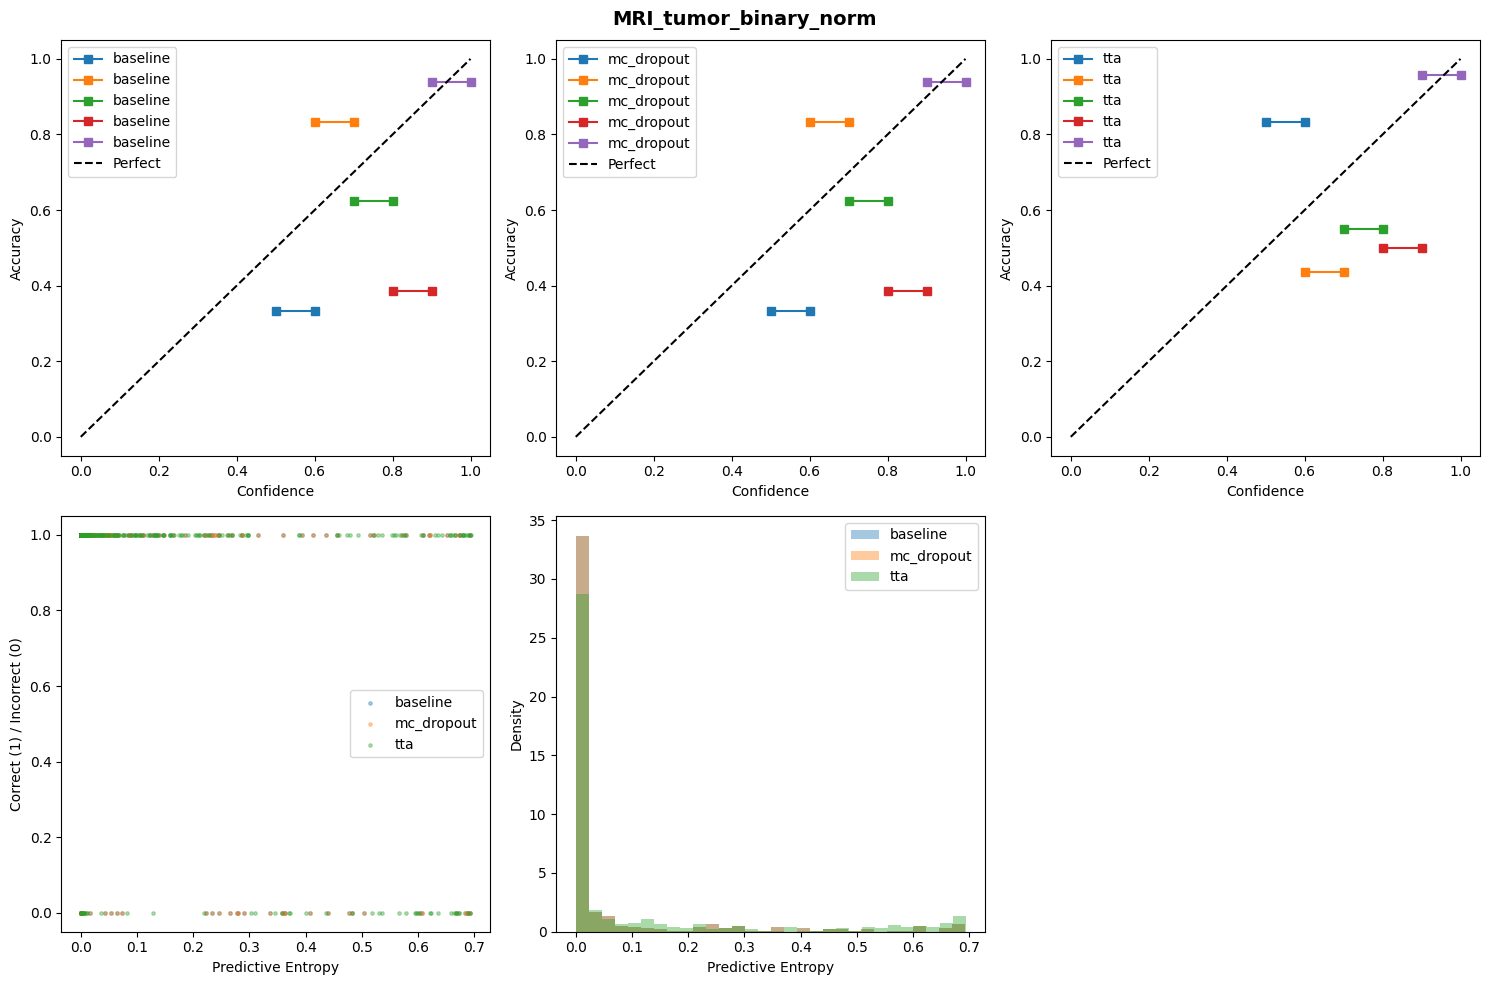

🧠 Running Uncertainty Benchmark for Neuroimaging...
✅ Test dataset loaded: 1197 samples
📁 Classes: ['Carcinoma', 'Germinoma', 'Glioma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Normal', 'Other', 'Papiloma', 'Schwannoma', 'Tuberculoma']
Using dataset: MRI_tumor_multiclass_norm
Classes: ['Carcinoma', 'Germinoma', 'Glioma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Normal', 'Other', 'Papiloma', 'Schwannoma', 'Tuberculoma']
Test samples: 1197

🔬 Evaluating uncertainty methods...


100%|██████████| 75/75 [12:19<00:00,  9.86s/it]


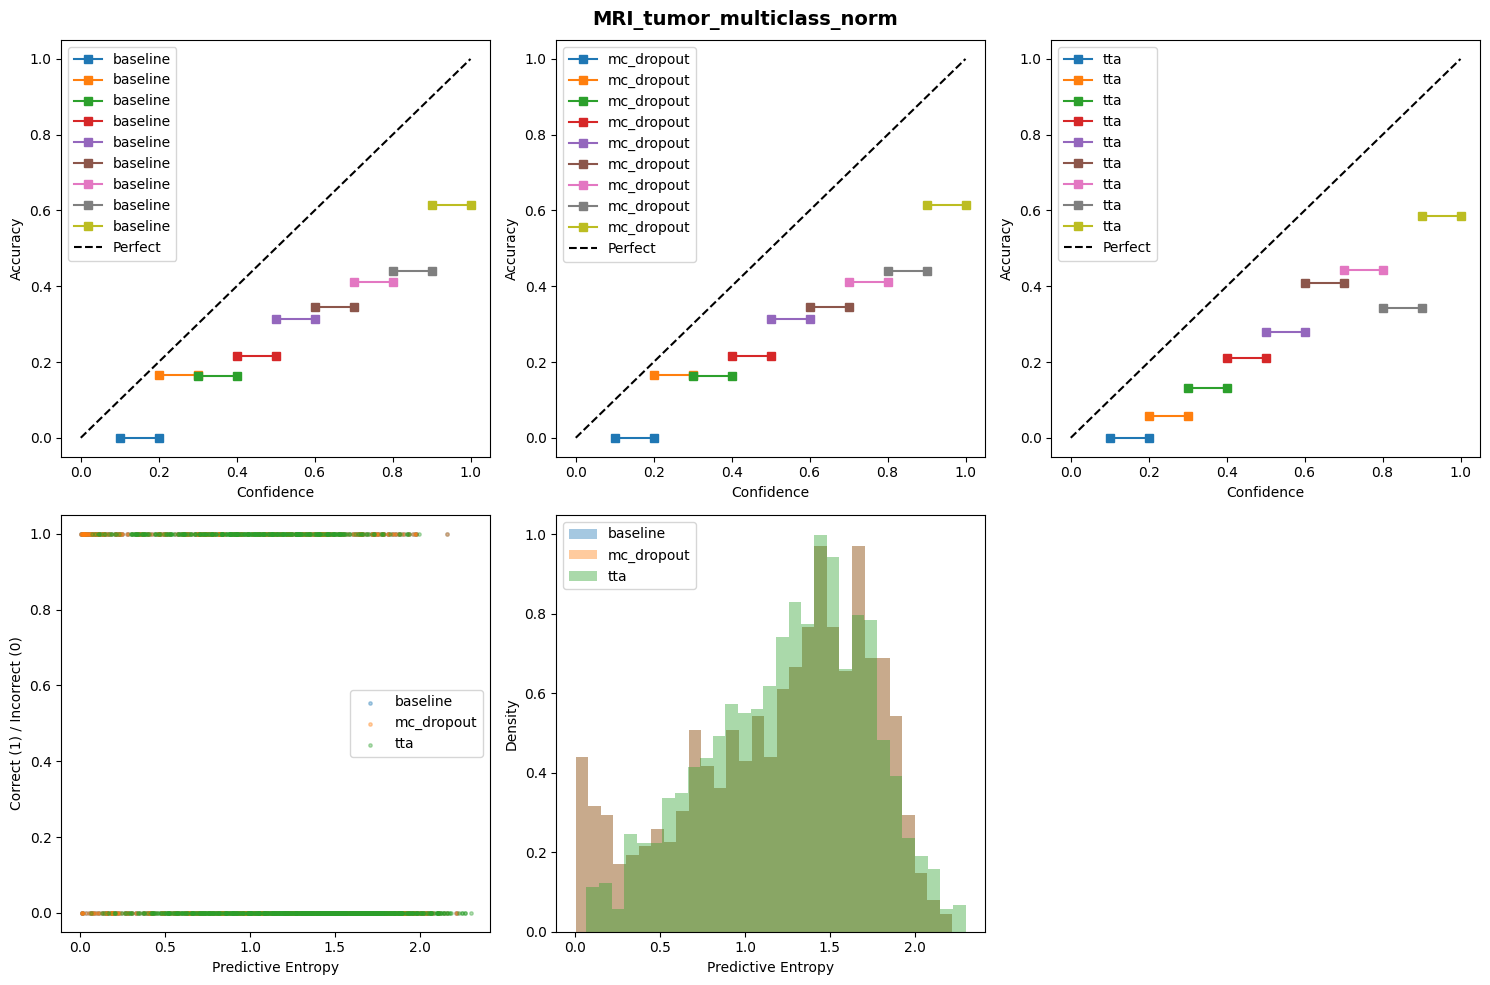

🧠 Running Uncertainty Benchmark for Neuroimaging...
✅ Test dataset loaded: 999 samples
📁 Classes: ['normal', 'stroke']
Using dataset: CT_stroke_binary_norm
Classes: ['normal', 'stroke']
Test samples: 999

🔬 Evaluating uncertainty methods...


100%|██████████| 63/63 [10:27<00:00,  9.96s/it]


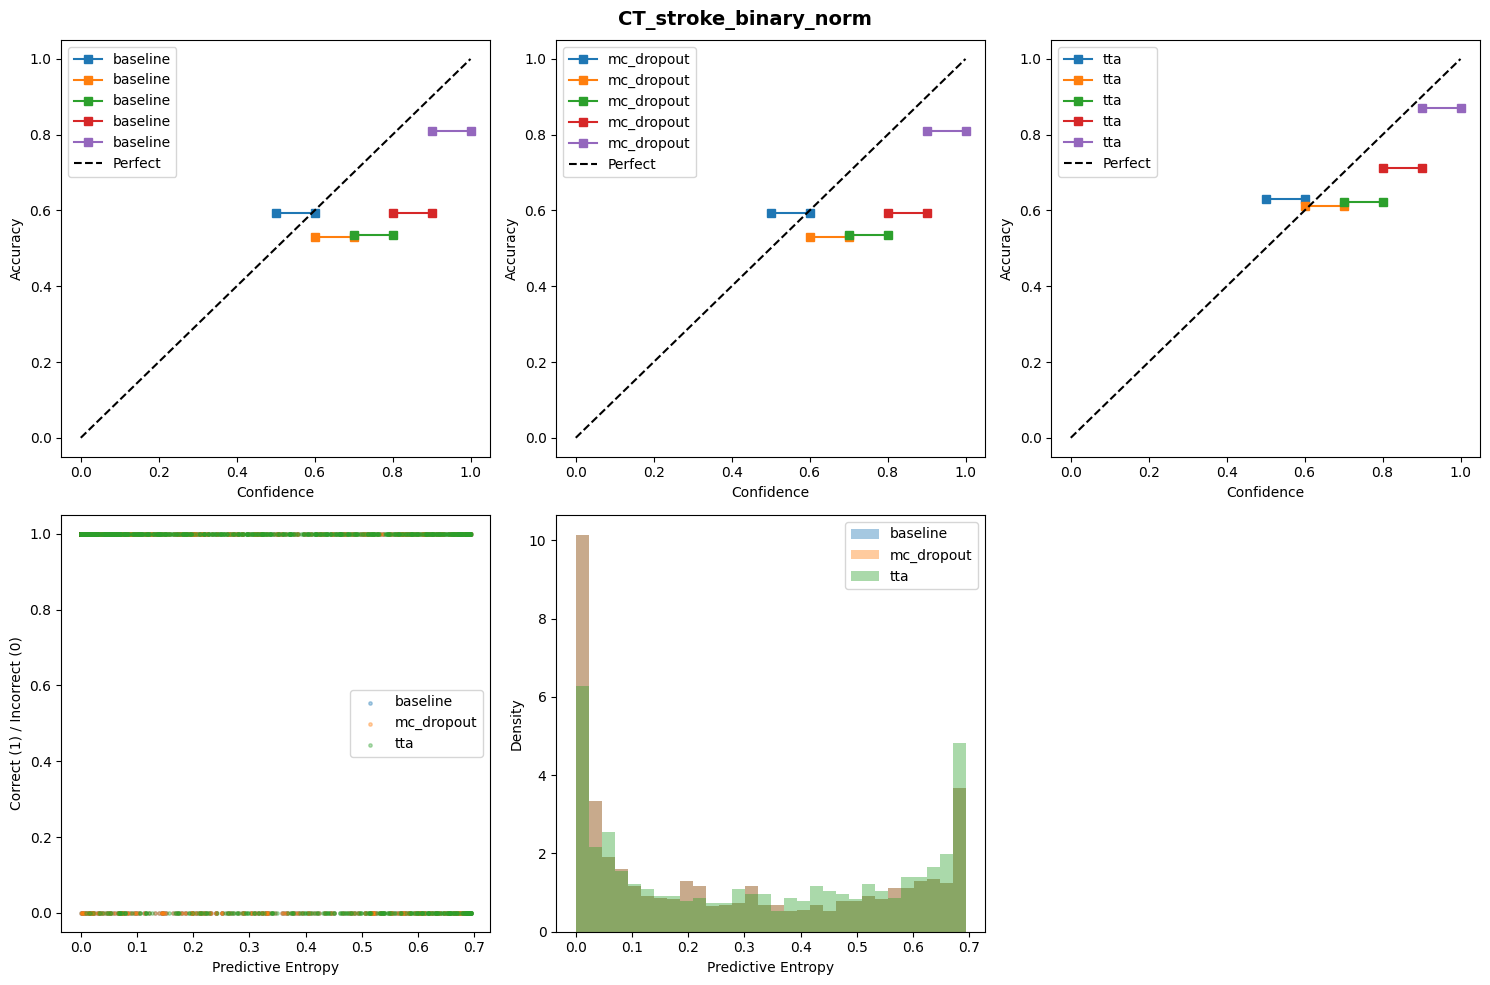

In [ ]:
all_results = run_all_datasets([
    "MRI_tumor_binary_norm",
    "MRI_tumor_multiclass_norm",
    "CT_stroke_binary_norm",
])

## Batch Run

Run the benchmark across multiple datasets and save plots.


🧠 Running Uncertainty Benchmark for Neuroimaging...
✅ Test dataset loaded: 586 samples
📁 Classes: ['Control', 'MS']
Using dataset: MRI_ms_norm
Classes: ['Control', 'MS']
Test samples: 586

🔬 Evaluating uncertainty methods...


100%|██████████| 37/37 [06:25<00:00, 10.43s/it]


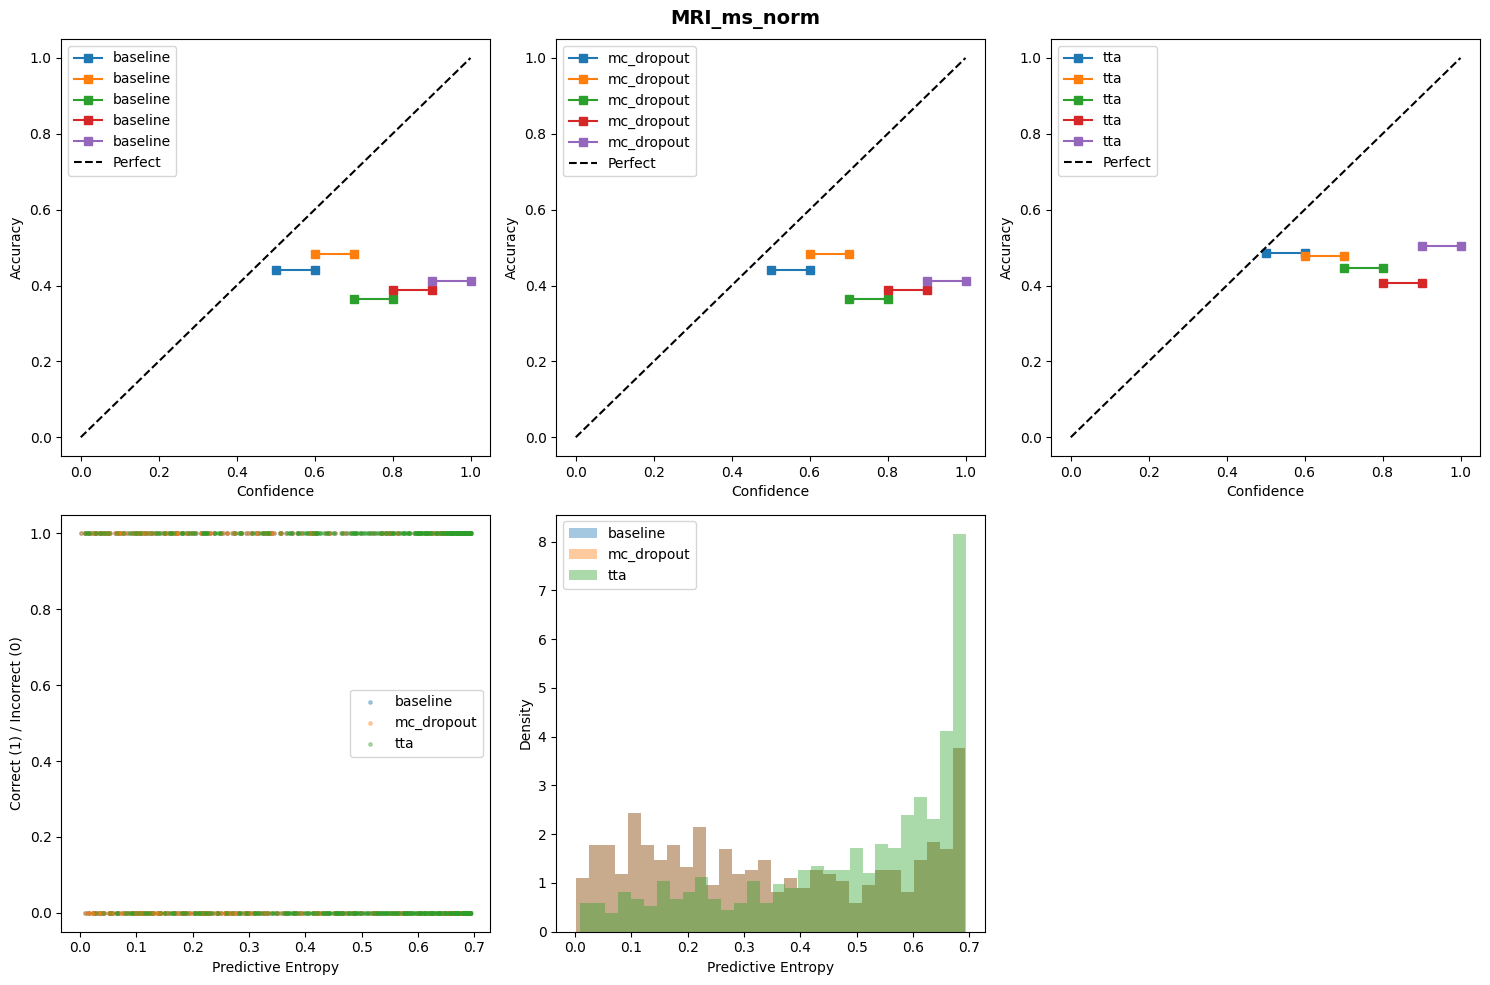

In [ ]:
results_ms = run_all_datasets(["MRI_ms_norm"])

In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.preprocessing import label_binarize

/home/tamara/.local/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Summarize results


In [ ]:
def summarize_results(results, labels):
    labels = labels.cpu().numpy() if torch.is_tensor(labels) else np.array(labels)
    rows = []
    for method in ['baseline', 'mc_dropout', 'tta']:
        probs = torch.cat(results[method]['probs']).cpu().numpy()
        preds = probs.argmax(axis=1)
        conf = probs.max(axis=1)

        acc = accuracy_score(labels, preds)
        nll = log_loss(labels, probs, labels=np.arange(probs.shape[1]))

        y_onehot = label_binarize(labels, classes=np.arange(probs.shape[1]))
        brier = np.mean(np.sum((probs - y_onehot) ** 2, axis=1))

        if probs.shape[1] == 2:
            auroc = roc_auc_score(labels, probs[:, 1])
        else:
            auroc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')

        entropy = -np.sum(probs * np.log(probs + 1e-8), axis=1).mean()

        rows.append({
            "method": method,
            "ECE": float(results[method]['ece']),
            "Accuracy": float(acc),
            "AUROC": float(auroc),
            "NLL": float(nll),
            "Brier": float(brier),
            "MeanEntropy": float(entropy),
            "MeanConfidence": float(conf.mean()),
        })
    return pd.DataFrame(rows)

def pretty_print(df, title=None):
    if title:
        print(f"\n=== {title} ===")
    display(df.style.format({
        "ECE": "{:.4f}",
        "Accuracy": "{:.4f}",
        "AUROC": "{:.4f}",
        "NLL": "{:.4f}",
        "Brier": "{:.4f}",
        "MeanEntropy": "{:.4f}",
        "MeanConfidence": "{:.4f}",
    }))

In [ ]:
combined = {}
combined.update(all_results)
combined.update(results_ms)

all_tables = []

for ds, payload in combined.items():
    df = summarize_results(payload['results'], payload['labels'])
    df.insert(0, "dataset", ds)
    all_tables.append(df)
    pretty_print(df, title=ds)
    df.to_csv(f"uncertainty_metrics_{ds}.csv", index=False)

df_all = pd.concat(all_tables, ignore_index=True)
df_all.to_csv("uncertainty_metrics_all_datasets.csv", index=False)
print("Saved: uncertainty_metrics_all_datasets.csv")


=== MRI_tumor_binary_norm ===


,dataset,method,ECE,Accuracy,AUROC,NLL,Brier,MeanEntropy,MeanConfidence
0,MRI_tumor_binary_norm,baseline,0.0700,0.9089,0.9663,0.5178,0.9647,0.0594,0.9759
1,MRI_tumor_binary_norm,mc_dropout,0.0700,0.9089,0.9661,0.5178,0.9647,0.0594,0.9759
2,MRI_tumor_binary_norm,tta,0.0656,0.9022,0.9690,0.4036,0.9337,0.1067,0.9529



=== MRI_tumor_multiclass_norm ===


,dataset,method,ECE,Accuracy,AUROC,NLL,Brier,MeanEntropy,MeanConfidence
0,MRI_tumor_multiclass_norm,baseline,0.2625,0.3200,0.6523,2.5496,0.8994,1.2007,0.5824
1,MRI_tumor_multiclass_norm,mc_dropout,0.2625,0.3200,0.6523,2.5496,0.8994,1.2007,0.5824
2,MRI_tumor_multiclass_norm,tta,0.2784,0.2840,0.6473,2.6115,0.9334,1.2570,0.5625



=== CT_stroke_binary_norm ===


,dataset,method,ECE,Accuracy,AUROC,NLL,Brier,MeanEntropy,MeanConfidence
0,CT_stroke_binary_norm,baseline,0.1698,0.7147,0.8181,0.7834,0.8280,0.2720,0.8772
1,CT_stroke_binary_norm,mc_dropout,0.1698,0.7147,0.8181,0.7834,0.8280,0.2720,0.8772
2,CT_stroke_binary_norm,tta,0.1030,0.7618,0.8352,0.5766,0.7889,0.3292,0.8476



=== MRI_ms_norm ===


,dataset,method,ECE,Accuracy,AUROC,NLL,Brier,MeanEntropy,MeanConfidence
0,MRI_ms_norm,baseline,0.4382,0.4113,0.5205,1.5247,0.7834,0.3474,0.8494
1,MRI_ms_norm,mc_dropout,0.4382,0.4113,0.5205,1.5247,0.7834,0.3474,0.8494
2,MRI_ms_norm,tta,0.2990,0.4642,0.5317,1.0562,0.6774,0.4860,0.7608


Saved: uncertainty_metrics_all_datasets.csv
